**Local Feature Matching with Transformers (LoFTR)**

LoFTR was proposed in LoFTR: Detector-Free Local Feature Matching with Transformers by Sun, et. al. Instead of using feature detectors, LoFTR uses a learning-based approach to feature matching.

Let’s keep it simple and use our puzzle example once again. Instead of simply comparing images pixel by pixel, LoFTR looks for specific key points, or features, in each image. It’s like identifying the corners and edges of each puzzle piece. And just as someone really good a putting together a puzzle might focus on distinctive marks, LoFTR identifies these unique points in one image. These could be key landmarks or structures that stand out. As we have already learned, it is important that the matching algorithm handles changes in rotation or scale. If a feature is turned or resized, LoFTR would still recognize it. It’s like solving puzzles where pieces may be flipped or adjusted. As LoFTR matches features, it assigns a similarity score to indicate how well the features align. Higher scores mean better matches. It’s like giving a grade to how well one puzzle piece fits with another. LoFTR is also invariant to certain transformations, meaning it can handle variations in lighting, angle, or perspective. This is crucial when dealing with images that might be photographed under different conditions. LoFTR’s ability to robustly match features makes it valuable for tasks like image stitching, where you combine multiple images seamlessly by identifying and connecting common features.

We can use Kornia to find matching features in two images using LoFTR.

In [5]:
import cv2
import kornia as K
import kornia.feature as KF
import matplotlib.pyplot as plt
import numpy as np
import torch
from kornia_moons.viz import draw_LAF_matches
from kornia.feature import LoFTR

In [18]:
# 1. Load image using OpenCV and convert to a Float Tensor [0, 1]
def load_image_alt(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Convert HWC to CHW format, scale to [0, 1], and add batch dimension [None, ...]
    tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return tensor[None, ...]

img1 = load_image_alt('../data/target/target.jpg')
# img2 = load_image_alt('../data/query/query1.jpg')
img2 = load_image_alt('../data/target/target.jpg')

# 2. Continue with your resizing logic
img1 = K.geometry.resize(img1, (512, 512), antialias=True)
img2 = K.geometry.resize(img2, (512, 512), antialias=True)

In [19]:
matcher = LoFTR(pretrained="outdoor")

In [20]:
input_dict = {
    "image0": K.color.rgb_to_grayscale(img1),
    "image1": K.color.rgb_to_grayscale(img2),
}

In [21]:
with torch.inference_mode():
    correspondences = matcher(input_dict)

In [22]:
mkpts0 = correspondences["keypoints0"].cpu().numpy()
mkpts1 = correspondences["keypoints1"].cpu().numpy()
Fm, inliers = cv2.findFundamentalMat(mkpts0, mkpts1, cv2.USAC_MAGSAC, 0.5, 0.999, 100000)
inliers = inliers > 0

/tmp/ipykernel_44724/455232558.py:13: DeprecationWarning: Since kornia 0.8.3 the `tensor_to_image` is deprecated in favor of `kornia.image.tensor_to_image`.
  K.tensor_to_image(img1),
/tmp/ipykernel_44724/455232558.py:14: DeprecationWarning: Since kornia 0.8.3 the `tensor_to_image` is deprecated in favor of `kornia.image.tensor_to_image`.
  K.tensor_to_image(img2),
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


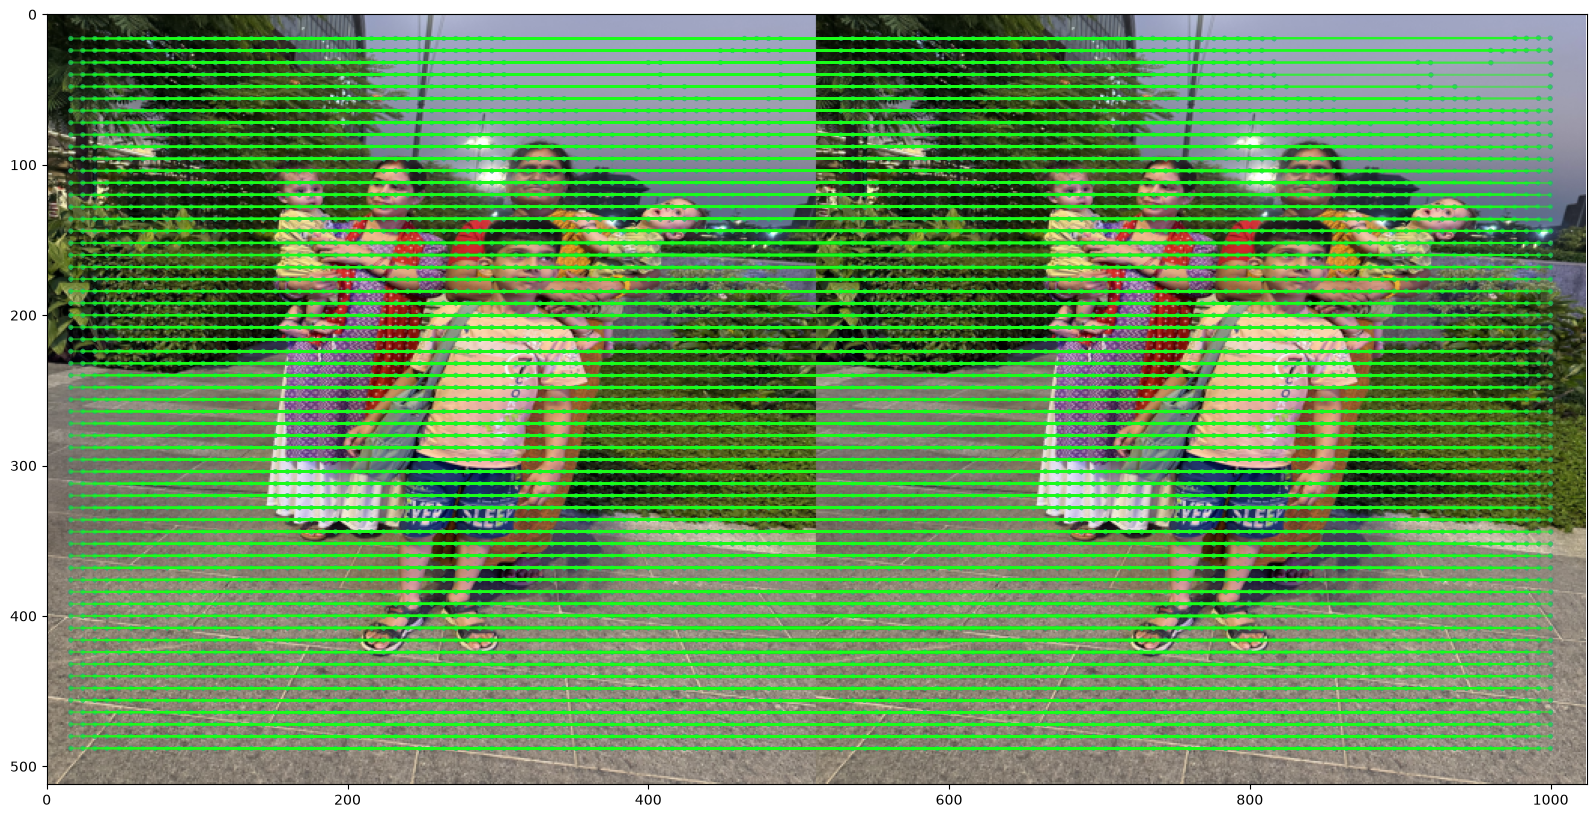

In [23]:
draw_LAF_matches(
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts0).view(1, -1, 2),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1),
    ),
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts1).view(1, -1, 2),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1),
    ),
    torch.arange(mkpts0.shape[0]).view(-1, 1).repeat(1, 2),
    K.tensor_to_image(img1),
    K.tensor_to_image(img2),
    inliers,
    draw_dict={
        "inlier_color": (0.1, 1, 0.1, 0.5),
        "tentative_color": None,
        "feature_color": (0.2, 0.2, 1, 0.5),
        "vertical": False,
    },
)